<a href="https://colab.research.google.com/github/Pushkar360/BML-/blob/main/BML_Exp_1_tp_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.stats import mode


file_path = "/content/winequality-red.csv"
df = pd.read_csv(file_path, sep=';')


df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [2]:
df = pd.read_csv(file_path, sep=',')


if df.shape[1] == 1:
    df = pd.read_csv(file_path, sep=';')


df.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


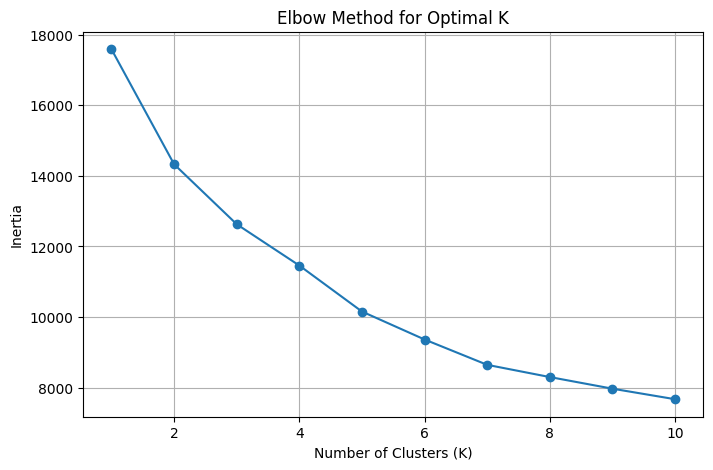

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop(columns=['quality']))


inertia = []
k_values = range(1, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linestyle='-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.grid(True)
plt.show()

K-Means Clustering Accuracy: 0.55
Confusion Matrix:
 [[  0   0   8   2   0   0]
 [  0   0  45   8   0   0]
 [  0   0 542 139   0   0]
 [  0   0 300 338   0   0]
 [  0   0  39 160   0   0]
 [  0   0   1  17   0   0]]


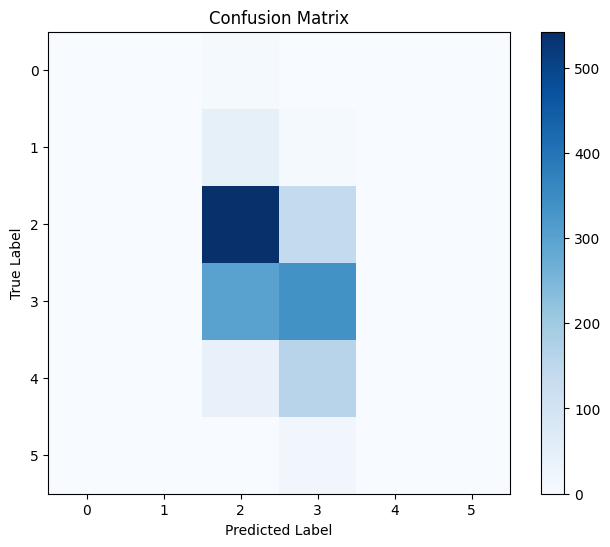

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from scipy.stats import mode

# Load dataset
file_path = "/content/winequality-red.csv"
df = pd.read_csv(file_path, sep=';')

# Extract features and target
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means with chosen K (assumed optimal: 6)
optimal_k = 6
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Compare clusters with actual quality labels
cluster_labels = df['cluster'].values

# Majority voting: Map clusters to actual quality labels
cluster_to_quality = {}

for cluster in range(optimal_k):
    cluster_indices = np.where(cluster_labels == cluster)[0]  # Get indices of samples in cluster
    if len(cluster_indices) > 0:  # Ensure cluster is not empty
        most_common_quality = mode(y[cluster_indices], keepdims=True).mode[0]  # Find most frequent quality label
        cluster_to_quality[cluster] = most_common_quality

# Convert cluster labels to predicted quality labels
predicted_labels = np.array([cluster_to_quality[cluster] for cluster in cluster_labels])

# Calculate accuracy
accuracy = accuracy_score(y, predicted_labels)
conf_matrix = confusion_matrix(y, predicted_labels)

# Print results
print(f'K-Means Clustering Accuracy: {accuracy:.2f}')
print('Confusion Matrix:\n', conf_matrix)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, cmap='Blues', interpolation='nearest')
plt.colorbar()
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()